In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
import os

base_path = r"D:/python\Shreyians ML/6. CNN/archive"

folders = os.listdir(base_path)

print("Number of folders:", len(folders))
print("First 10 folders:", folders[:10])

Number of folders: 280
First 10 folders: ['10253', '10254', '10255', '10256', '10257', '10258', '10259', '10260', '10261', '10262']


In [3]:
count_0 = 0
count_1 = 0

for folder in os.listdir(base_path):
    folder_path = os.path.join(base_path, folder)

    if not os.path.isdir(folder_path):
        continue

    class_0 = os.path.join(folder_path, "0")
    class_1 = os.path.join(folder_path, "1")

    if os.path.exists(class_0):
        count_0 += len(os.listdir(class_0))

    if os.path.exists(class_1):
        count_1 += len(os.listdir(class_1))

print("Cancer not detected (0):", count_0)
print("Cancer detected (1):", count_1)
print("Total images:", count_0 + count_1)

Cancer not detected (0): 198738
Cancer detected (1): 78786
Total images: 277524


In [4]:
output_path = r"D:/python\Shreyians ML/6. CNN/CancerDataset"

os.makedirs(os.path.join(output_path, "0"), exist_ok=True)
os.makedirs(os.path.join(output_path, "1"), exist_ok=True)

print("Dataset folders created.")

Dataset folders created.


In [6]:
import shutil
for folder in os.listdir(base_path):

    folder_path = os.path.join(base_path, folder)

    if not os.path.isdir(folder_path):
        continue

    for label in ["0", "1"]:

        class_path = os.path.join(folder_path, label)

        if not os.path.exists(class_path):
            continue

        for image in os.listdir(class_path):

            source = os.path.join(class_path, image)

            # Create a unique filename because different folders
            # may contain images with the same filename
            new_name = f"{folder}_{image}"

            destination = os.path.join(
                output_path,
                label,
                new_name
            )

            shutil.copy2(source, destination)

print("Images copied successfully.")

Images copied successfully.


In [1]:
import tensorflow as tf

dataset_path = r"D:/python\Shreyians ML/6. CNN/CancerDataset"

train_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(224, 224),
    batch_size=32,
    label_mode="binary"
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(224, 224),
    batch_size=32,
    label_mode="binary"
)

Found 277524 files belonging to 2 classes.
Using 222020 files for training.
Found 277524 files belonging to 2 classes.
Using 55504 files for validation.


In [4]:
for images, labels in train_dataset.take(1):
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)

Images shape: (32, 224, 224, 3)
Labels shape: (32, 1)


In [5]:
len(train_dataset)

6939

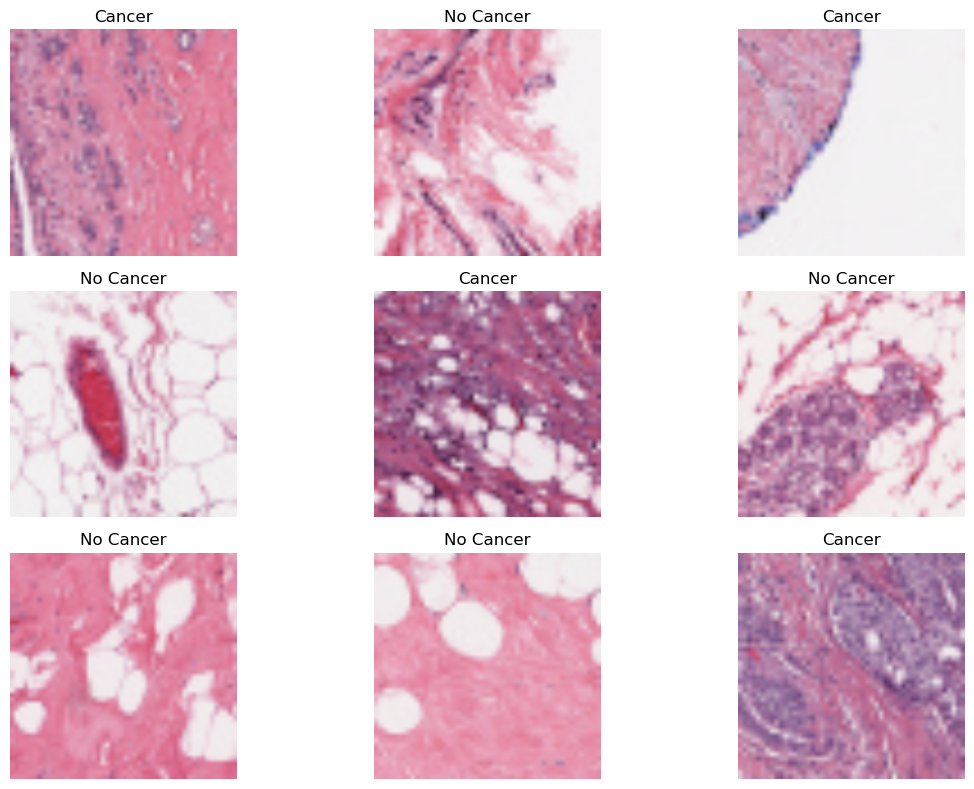

In [7]:
import matplotlib.pyplot as plt

for images, labels in train_dataset.take(1):

    plt.figure(figsize=(12, 8))

    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        label = int(labels[i].numpy()[0])

        if label == 0:
            title = "No Cancer"
        else:
            title = "Cancer"

        plt.title(title)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [8]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_dataset = train_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

validation_dataset = validation_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

In [15]:
train_small = train_dataset.take(1563)
val_small = validation_dataset.take(313)

In [16]:
train_count = 0

for images, labels in train_small:
    train_count += images.shape[0]

print("Training images:", train_count)

Training images: 50016


In [17]:
for images, labels in train_small.take(1):
    print("Training images shape:", images.shape)
    print("Training labels shape:", labels.shape)

Training images shape: (32, 224, 224, 3)
Training labels shape: (32, 1)


# Model 1 Training

In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D, Flatten, Dense, Dropout

In [19]:
model=Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)),
    MaxPooling2D(),
    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(),
    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D(),
    Flatten(),
    Dense(128,activation='relu'),
    Dropout(0.2),
    Dense(64,activation='relu'),
    Dropout(0.4),
    Dense(32,activation='relu'),
    Dropout(0.5),
    Dense(1,activation='sigmoid')
])

d:\Anaconda\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [21]:
history=model.fit(train_small,validation_data=val_small,epochs=2)

Epoch 1/2
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18803s 12s/step - accuracy: 0.7532 - loss: 0.5283 - val_accuracy: 0.8395 - val_loss: 0.3848
Epoch 2/2
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2967s 2s/step - accuracy: 0.8243 - loss: 0.4098 - val_accuracy: 0.8472 - val_loss: 0.3523


In [22]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


In [23]:
print("Training accuracy:", history.history['accuracy'])
print("Validation accuracy:", history.history['val_accuracy'])

print("Training loss:", history.history['loss'])
print("Validation loss:", history.history['val_loss'])

Training accuracy: [0.7918466329574585, 0.8275551795959473]
Validation accuracy: [0.8394568562507629, 0.847244381904602]
Training loss: [0.47605234384536743, 0.4053635895252228]
Validation loss: [0.384787917137146, 0.35234424471855164]


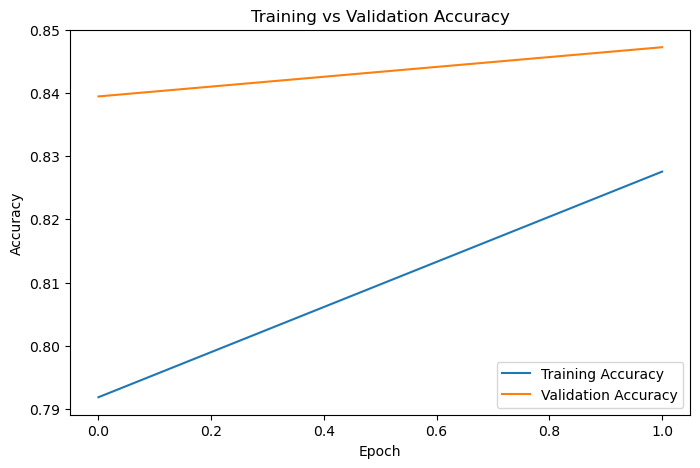

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')

plt.legend()
plt.show()

In [25]:
loss, accuracy = model.evaluate(val_small)

print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 149s 465ms/step - accuracy: 0.8517 - loss: 0.3467
Validation Loss: 0.35299181938171387
Validation Accuracy: 0.8471445441246033


In [27]:
import numpy as np
y_true = []
y_pred_prob = []

for images, labels in val_small:

    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy().flatten())
    y_pred_prob.extend(predictions.flatten())

y_true = np.array(y_true)
y_pred_prob = np.array(y_pred_prob)

In [28]:
y_pred = (y_pred_prob >= 0.5).astype(int)

# Classification Report

In [31]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=['No Cancer', 'Cancer']
    )
)

              precision    recall  f1-score   support

   No Cancer       0.89      0.90      0.89      7174
      Cancer       0.74      0.71      0.73      2842

    accuracy                           0.85     10016
   macro avg       0.81      0.81      0.81     10016
weighted avg       0.85      0.85      0.85     10016



In [32]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)
cm

array([[6455,  719],
       [ 816, 2026]], dtype=int64)

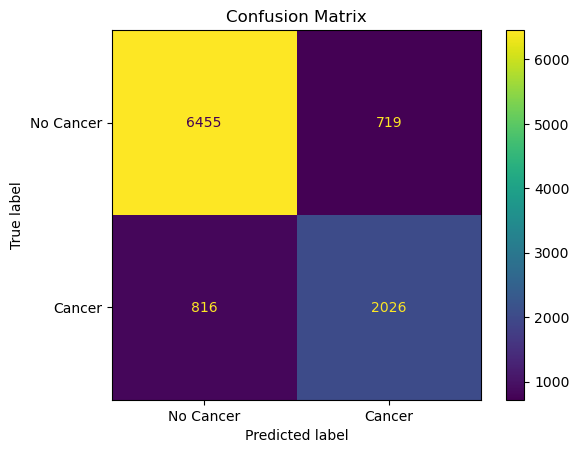

In [33]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No Cancer', 'Cancer']
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()

In [35]:
from sklearn.metrics import accuracy_score
acc=accuracy_score(y_true,y_pred)
acc

0.8467452076677316

In [36]:
from sklearn.metrics import recall_score
recall=recall_score(y_true,y_pred)
recall

0.712878254750176

# Model 2

In [38]:
model2=Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)),
    MaxPooling2D(),
    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(),
    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D(),
    Flatten(),
    Dense(128,activation='relu'),
    Dense(64,activation='relu'),
    Dense(32,activation='relu'),
    Dense(1,activation='sigmoid')
])

d:\Anaconda\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [39]:
model2.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [40]:
history2=model2.fit(train_small,validation_data=val_small,epochs=2)

Epoch 1/2
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 3290s 2s/step - accuracy: 0.7936 - loss: 0.4533 - val_accuracy: 0.8387 - val_loss: 0.3702
Epoch 2/2
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 3220s 2s/step - accuracy: 0.8344 - loss: 0.3800 - val_accuracy: 0.8461 - val_loss: 0.3659


In [41]:
print("Training accuracy:", history2.history['accuracy'])
print("Validation accuracy:", history2.history['val_accuracy'])

print("Training loss:", history2.history['loss'])
print("Validation loss:", history2.history['val_loss'])

Training accuracy: [0.8180182576179504, 0.8367522358894348]
Validation accuracy: [0.8386581540107727, 0.8461461663246155]
Training loss: [0.41507717967033386, 0.3764502704143524]
Validation loss: [0.37022387981414795, 0.36587706208229065]


In [43]:
import numpy as np
y_true2 = []
y_pred_prob2 = []

for images, labels in val_small:

    predictions2 = model2.predict(images, verbose=0)

    y_true2.extend(labels.numpy().flatten())
    y_pred_prob2.extend(predictions2.flatten())

y_true2 = np.array(y_true2)
y_pred_prob2 = np.array(y_pred_prob2)

In [44]:
y_pred2 = (y_pred_prob2 >= 0.5).astype(int)

In [45]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true2,
        y_pred2,
        target_names=['No Cancer', 'Cancer']
    )
)

              precision    recall  f1-score   support

   No Cancer       0.87      0.92      0.90      7191
      Cancer       0.76      0.66      0.71      2825

    accuracy                           0.85     10016
   macro avg       0.82      0.79      0.80     10016
weighted avg       0.84      0.85      0.84     10016



In [46]:
from sklearn.metrics import accuracy_score
acc2=accuracy_score(y_true2,y_pred2)
acc2

0.8461461661341853

In [47]:
from sklearn.metrics import recall_score
recall2=recall_score(y_true2,y_pred2)
recall2

0.6608849557522124

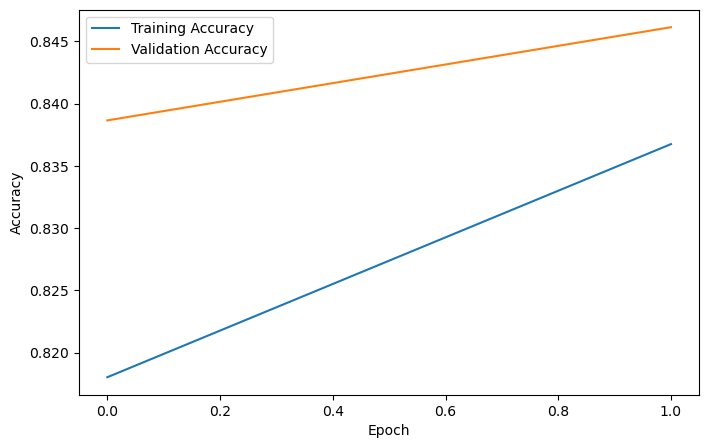

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history2.history['accuracy'], label='Training Accuracy')
plt.plot(history2.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

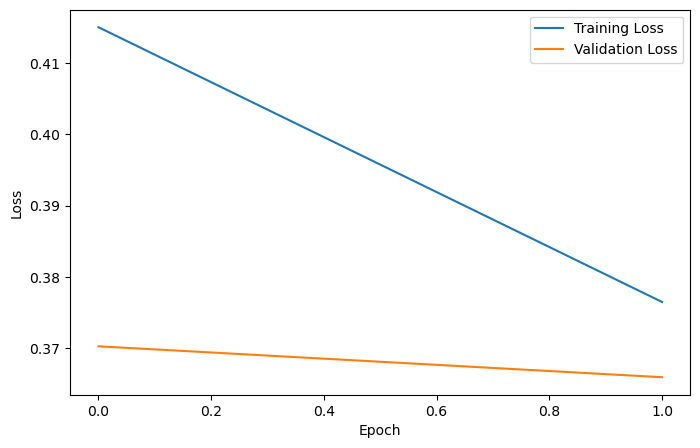

In [49]:
plt.figure(figsize=(8,5))
plt.plot(history2.history['loss'], label='Training Loss')
plt.plot(history2.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Model3 with class weights

In [50]:
import numpy as np

train_labels = []

for images, labels in train_small:
    train_labels.extend(labels.numpy().flatten())

train_labels = np.array(train_labels)

unique, counts = np.unique(train_labels, return_counts=True)

print(dict(zip(unique, counts)))

{0.0: 35748, 1.0: 14268}


In [51]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.array([0, 1])

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=np.array(train_labels)
)

class_weights = {
    0: class_weights_array[0],
    1: class_weights_array[1]
}

print(class_weights)

{0: 0.6995636119503189, 1: 1.7527333894028596}


In [53]:
history2 = model2.fit(
    train_small,
    validation_data=val_small,
    epochs=2,
    class_weight=class_weights
)

Epoch 1/2
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2578s 2s/step - accuracy: 0.7739 - loss: 0.5097 - val_accuracy: 0.7443 - val_loss: 0.5289
Epoch 2/2
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9121s 6s/step - accuracy: 0.8046 - loss: 0.4259 - val_accuracy: 0.8072 - val_loss: 0.4312


In [54]:
print("Training accuracy:", history2.history['accuracy'])
print("Validation accuracy:", history2.history['val_accuracy'])

print("Training loss:", history2.history['loss'])
print("Validation loss:", history2.history['val_loss'])

Training accuracy: [0.7764915227890015, 0.8106606006622314]
Validation accuracy: [0.74430912733078, 0.8072084784507751]
Training loss: [0.4894118309020996, 0.419171541929245]
Validation loss: [0.5288942456245422, 0.431242972612381]


In [55]:
import numpy as np
y_true2 = []
y_pred_prob2 = []

for images, labels in val_small:

    predictions2 = model2.predict(images, verbose=0)

    y_true2.extend(labels.numpy().flatten())
    y_pred_prob2.extend(predictions2.flatten())

y_true2 = np.array(y_true2)
y_pred_prob2 = np.array(y_pred_prob2)
y_pred2 = (y_pred_prob2 >= 0.5).astype(int)

In [56]:
from sklearn.metrics import accuracy_score
acc2=accuracy_score(y_true2,y_pred2)
acc2

0.8072084664536742

In [57]:
from sklearn.metrics import recall_score
recall2=recall_score(y_true2,y_pred2)
recall2

0.8742937853107344